# Final Project Zoo Dataset

*Made by Diego Plumed Beortegui*

*March 2026*

# Data Description:
The data contain the features:
- hair
- feathers
- eggs
- milk
- airborne
- aquatic
- predator
- toothed
- backbone
- breathes
- venomous
- fins
- legs
- tail
- domestic
- catsize

And we would like to predict on the type of animal : (class attribute)
- Mammal: 1
- Bird: 2
- Reptile: 3
- Fish: 4
- Amphibian: 5
- Insect: 6
- Invertebrate: 7

## 1. Import Libraries

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading and Understanding (10 marks)

We firstly focus on the data itself, its shape, and peculiarities.

We read the data.

In [78]:
zoo_df = pd.read_csv('Zoo.csv')
zoo_df

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


And show its general information.

In [79]:
zoo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


We note that the zoo data set does not contain any missing values. Nevertheless, we check.

In [80]:
missing_summary = pd.DataFrame({
    'Missing Values': zoo_df.isnull().sum(),
    'Percentage (%)': zoo_df.isnull().mean() * 100
})

print(missing_summary)

             Missing Values  Percentage (%)
animal name               0             0.0
hair                      0             0.0
feathers                  0             0.0
eggs                      0             0.0
milk                      0             0.0
airborne                  0             0.0
aquatic                   0             0.0
predator                  0             0.0
toothed                   0             0.0
backbone                  0             0.0
breathes                  0             0.0
venomous                  0             0.0
fins                      0             0.0
legs                      0             0.0
tail                      0             0.0
domestic                  0             0.0
catsize                   0             0.0
type                      0             0.0


We show the general statistc metrics from our data.

In [81]:
zoo_df.describe()       

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


We display the class counts:

In [82]:
zoo_df['type'].value_counts().sort_index()

type
1    41
2    20
3     5
4    13
5     4
6     8
7    10
Name: count, dtype: int64

We construct a barplot to visualise them.

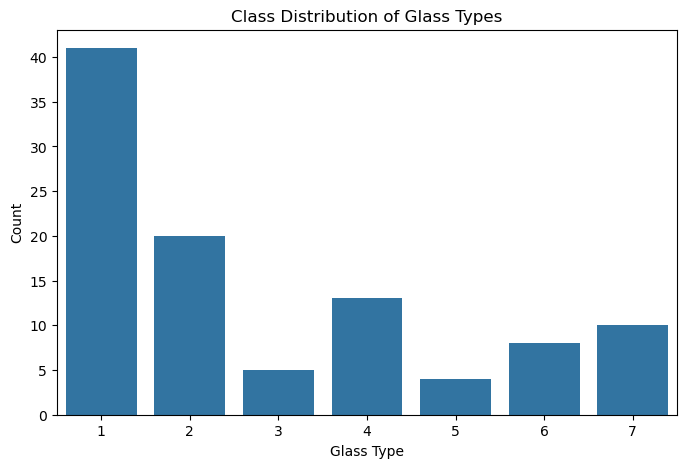

In [83]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=zoo_df, order=sorted(zoo_df['type'].unique()))

plt.title('Class Distribution of Glass Types')
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.show()

Again, we are dealing with an unbalanced dataset; we possess much more data for type 1 animals, more than double that of the others.

## 3. Data Understanding

In [84]:
zoo_df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In what follows, we identify and remove duplicate records.


In [85]:
zoo_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
96     False
97     False
98     False
99     False
100    False
Length: 101, dtype: bool

In [86]:
zoo_df[zoo_df.duplicated()]

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type


There are no duplicated rows in our dataset; the data was correctly drawn and processed.

## 4. Exploratory Data Analysis

### Outliers Detection

We proceed with our data analysis with outlier detection. We make use of box plots to do so.

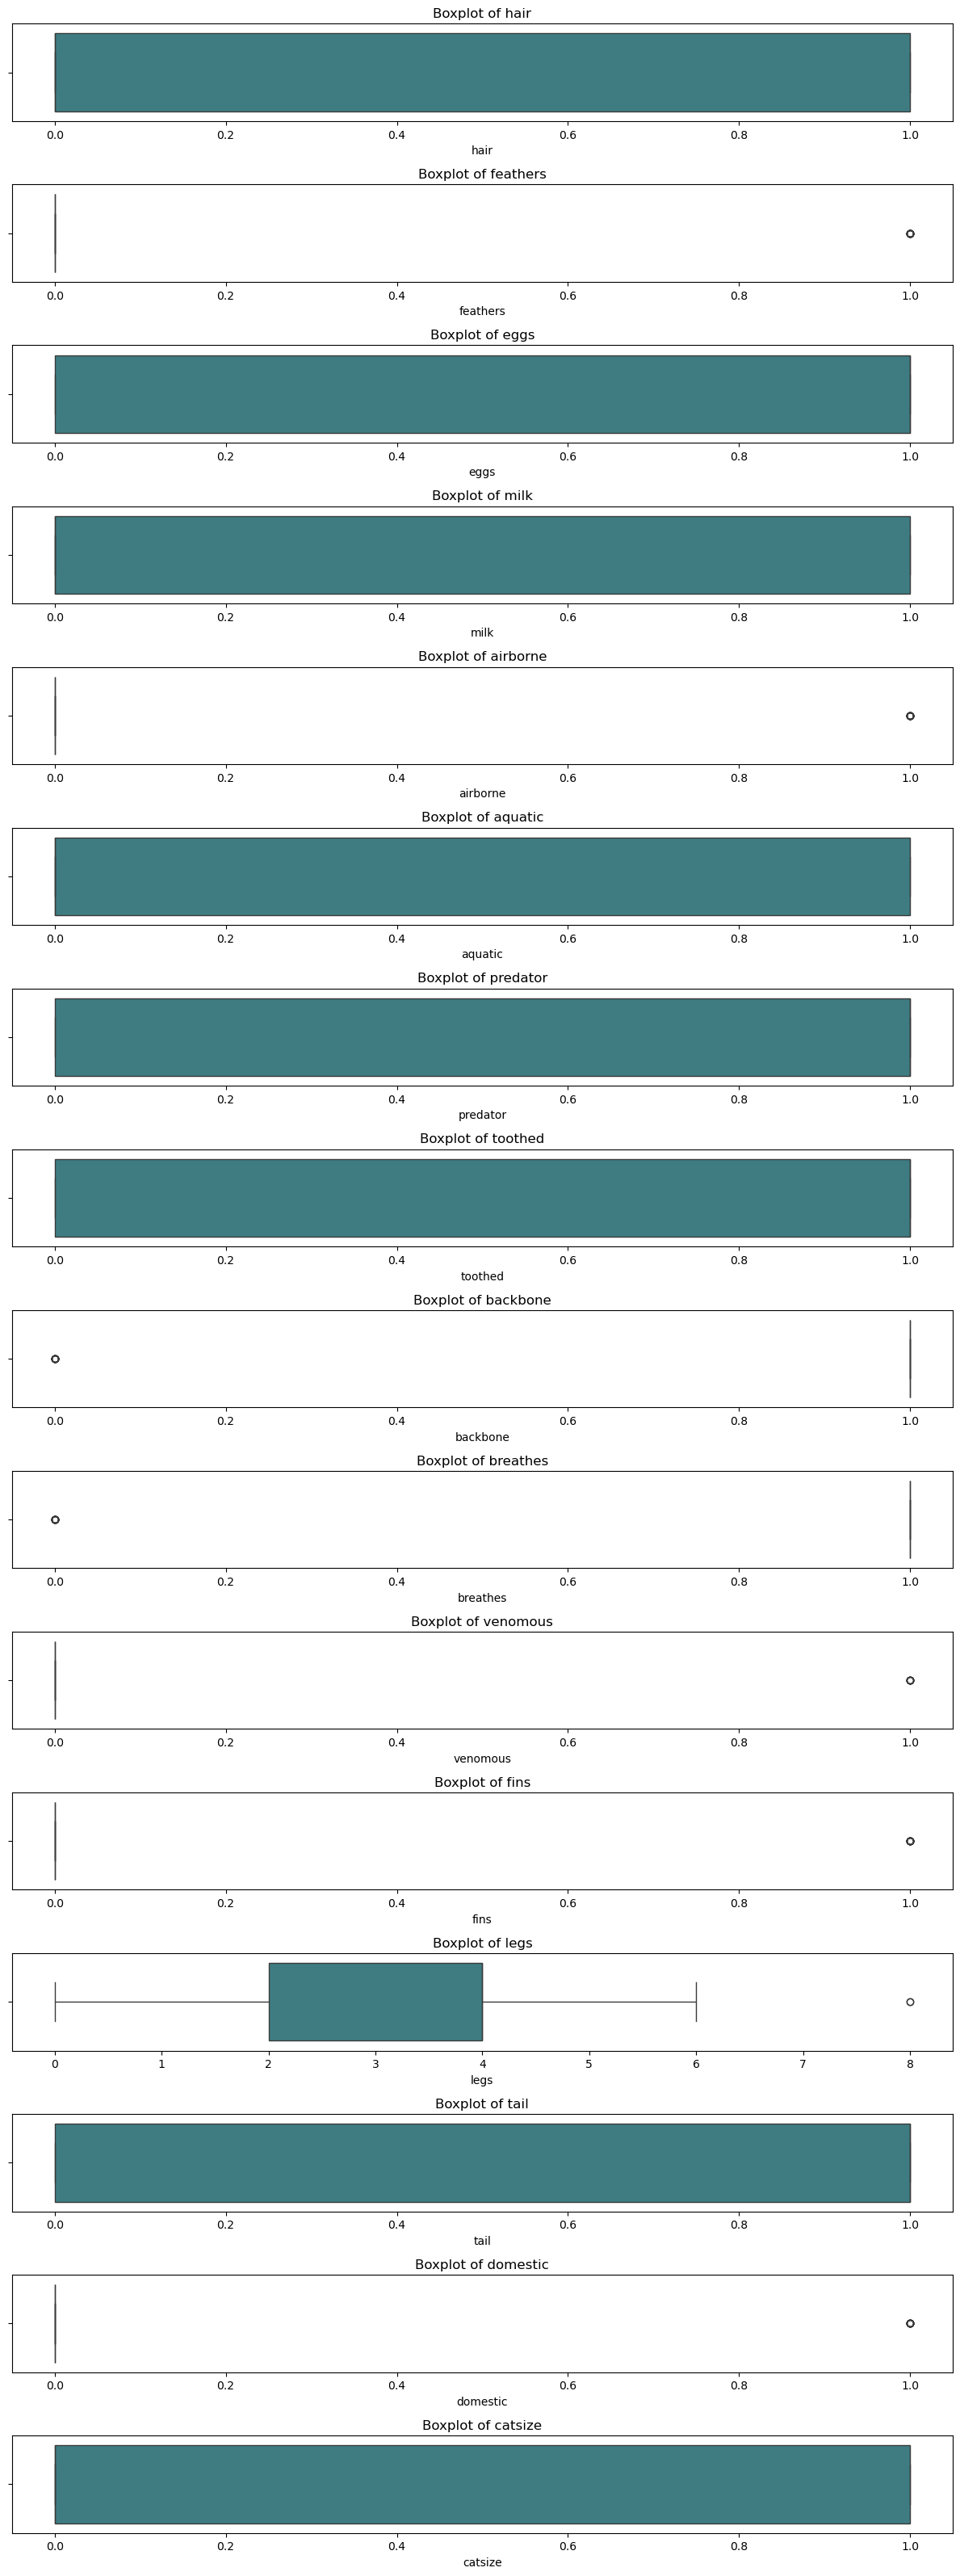

In [87]:

# Hint:fig, axes=plt.subplots(9,1,figsize=(12,12),sharex=False,sharey=False)
# sns.boxplot(x='RI',data=outlier,palette='crest',ax=axes[0]) 
#....

outlier = zoo_df.copy()

numerical_features = zoo_df.drop(columns=["animal name", "type"])

columns = numerical_features.columns

fig, ax = plt.subplots(len(columns), 1, 
                       figsize=(12,2*len(columns)),
                       sharex=False,
                       sharey=False)

for i, col in enumerate(columns):
    sns.boxplot(
        x=outlier[col],
        palette='crest',
        ax=ax[i]
    )
    ax[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

We may consider the 8-legged animals as the only outliers. However, they could prove to be substantially determinant for the model to learn proper patterns about insects.

###

## Multivariate Analysis

We study the dependence of our features through a confusion matrix.

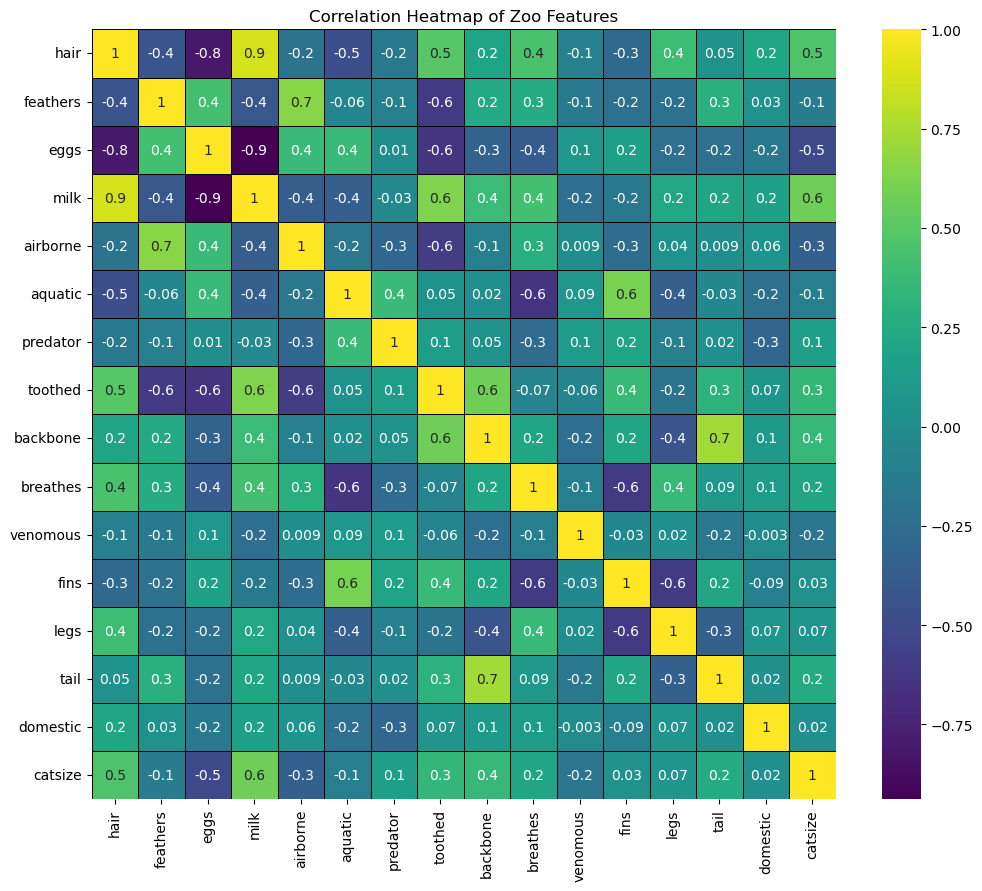

In [88]:
fig, ax = plt.subplots(figsize=(12,10))

sns.heatmap(numerical_features.corr(), 
            annot=True,         # Add annotations so correlation values on the heatmap are shown.
            fmt='.1g', 
            cmap="viridis",
            linewidths=0.5, 
            linecolor='black',
            ax = ax)

plt.title("Correlation Heatmap of Zoo Features")
plt.show()

This confusion matrix is indeed consistent with the real-world scenario. Note that features like milk and eggs, and tail and backbone are extremely correlated, whereas eggs and eggs, and milk and eggs are highly uncorrelated.

###

## 5. Data Pre-Processing

### 5.1 Hunting and removing multiple outliers

In this case, we will not remove the outliers from our data due to the previously stated reasoning.

### 5.2 Test Train Split

We split the data set into 80% training and 20% test.

In [89]:
X = zoo_df.drop(['animal name','type'],axis=1)
y = zoo_df[['type']]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2)

We check that the sizes accordingly correspond.

In [90]:
print("Shape of X_train : ",X_train.shape)
print("Shape of X_test  : ",X_test.shape)
print("Shape of y_train : ",y_train.shape)
print("Shape of y_test  : ",y_test.shape)

Shape of X_train :  (80, 16)
Shape of X_test  :  (21, 16)
Shape of y_train :  (80, 1)
Shape of y_test  :  (21, 1)


### 5.3 Standardize the Variables

We standarise the variable for the model to be stable.

In [91]:
std = StandardScaler()

X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

###

## 6. Choose the value for K.

### 6.1 Grid search for choosing the best Value of K

We compute the cross validation score and error to identify the best value of K for our data.

In [92]:
# Generate a list of odd k values from 1 to 39
# Odd numbers are often chosen to reduce tie votes in classification
k_list = np.arange(1, 40, 2)

# Lists to store evaluation metrics for each k
mean_scores = []     # Stores mean cross-validation accuracy
accuracy_list = []   # (Not currently used in loop)
error_rate = []      # Stores test error rate for each k

# Loop through each value of k
for i in k_list:
    
    # Create KNN model with current k
    knn = KNeighborsClassifier(n_neighbors=i)
    
    # Train the model on the training data
    knn.fit(X_train, y_train)
    
    # Predict labels on the test set
    pred_i = knn.predict(X_test)
    
    # Reshape predictions 
    pred_i = pred_i.reshape(21,1)
    
    # Perform 10-fold cross-validation on training data
    # This estimates generalization performance
    score = cross_val_score(knn, X_train, y_train, cv=10)
    
    # Store mean cross-validation accuracy
    mean_scores.append(np.mean(score))
    
    # Compute and store test error rate
    # Error rate = proportion of incorrect predictions
    error_rate.append(np.mean(pred_i != y_test))

We plot the results.

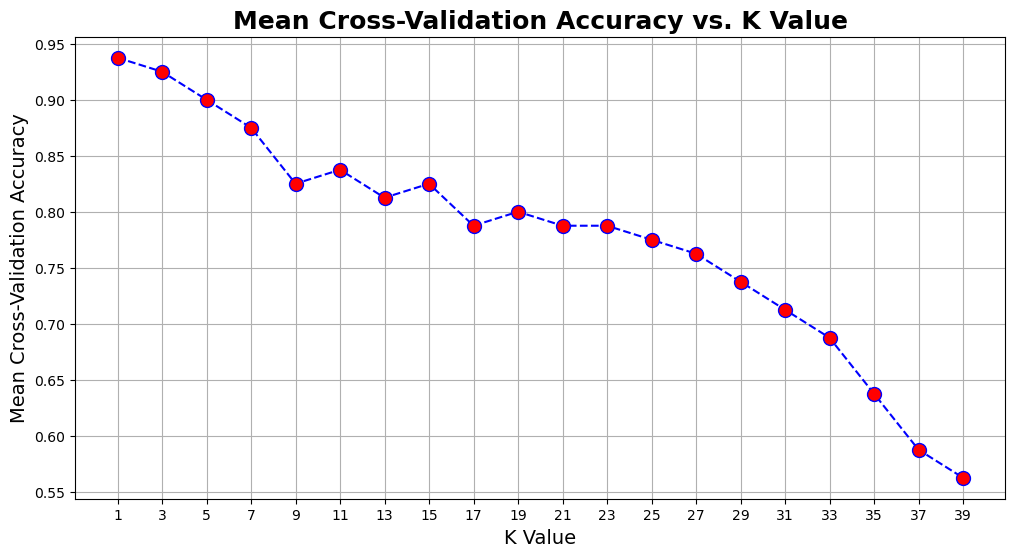

In [93]:
plt.figure(figsize=(12,6))
plt.plot(k_list, mean_scores, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Mean Cross-Validation Accuracy vs. K Value', fontsize=18, fontweight='bold')
plt.xlabel('K Value', fontsize=14)
plt.ylabel('Mean Cross-Validation Accuracy', fontsize=14)
plt.xticks(k_list)
plt.grid()
plt.show()

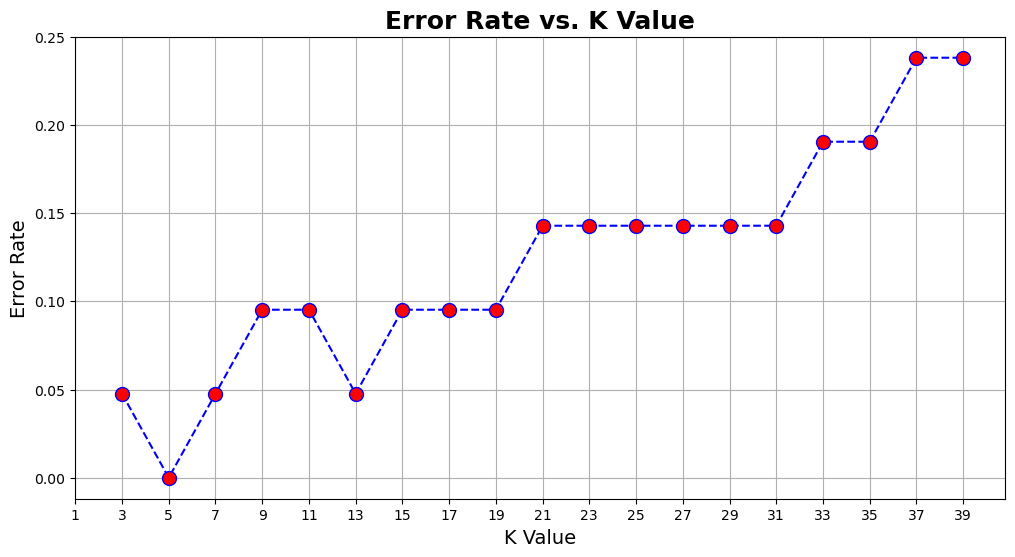

In [94]:
k_range = [i for i in range(3,40, 2)]

plt.figure(figsize=(12,6))
plt.plot(k_range, error_rate[1:], color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value', fontsize=18, fontweight='bold')
plt.xlabel('K Value', fontsize=14)
plt.ylabel('Error Rate', fontsize=14)
plt.xticks(k_list)
plt.grid()
plt.show()

We now utilise `GridSearchCV` as an advanced tool on the matter to fulfil our purpose.

In [95]:
n_neighbors = np.array([2*i+1 for i in range(1,20)])
param_grid = dict(n_neighbors=n_neighbors)
n_neighbors

array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35,
       37, 39])

In [96]:
param_grid

{'n_neighbors': array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35,
        37, 39])}

In [97]:
# Create a KNN classifier with default parameters
# (Hyperparameters like n_neighbors will be tuned via GridSearch)
model = KNeighborsClassifier()

# Create a GridSearch object
# - estimator: the base model to tune
# - param_grid: dictionary of hyperparameters to test (e.g., different k values)
# - perform 10-fold cross-validation for each parameter combination
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10
)

# Fit GridSearch to the full dataset (X features, y target)
grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 3, 5... 37, 39])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidat

In [98]:
print(f"The highest mean cross-validation accuracy found during GridSearch is {grid.best_score_}.")
print(f"The hyperparameter values that achieved the best cross-valiedation score are {grid.best_params_['n_neighbors']}.")
print(f"Thus, the best estimator is {grid.best_estimator_}.")

The highest mean cross-validation accuracy found during GridSearch is 0.95.
The hyperparameter values that achieved the best cross-valiedation score are 3.
Thus, the best estimator is KNeighborsClassifier(n_neighbors=np.int64(3)).


### 6.2 Visualizing the CV results

We visualise the results of the latter tool.

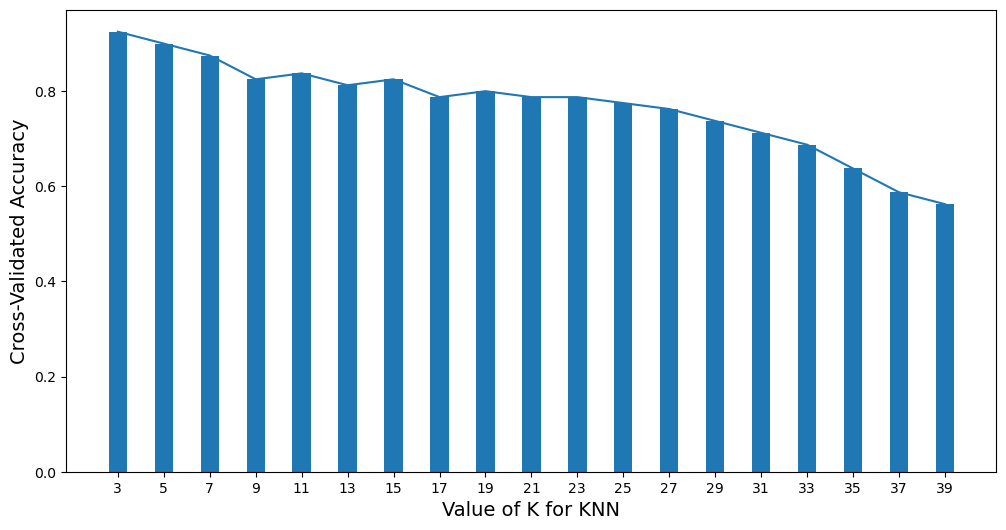

In [99]:
k_range = np.array([2*i+1 for i in range(1,20)])
k_scores = []

# use iteration to caclulator different k in models, then return the average accuracy based on the cross validation
for k in k_range:
    #Create a K-Nearest Neighbors (KNN) classifier with: n_neighbors = k
    knn = KNeighborsClassifier(n_neighbors= k)
    #perform 10-fold cross-validation on the KNN model
    #return an array called scores containing 10 accuracy values — one for each fold.
    scores = cross_val_score(knn, X_train, y_train, cv= 10)
    #compute the average cross-validation accuracy and store that average in the list k_scores.
    #Without this line, you would:
	#•	Only see raw fold scores
	#•	Not be able to compare k values easily
	#•	Not know which k performs best overall
    k_scores.append(np.mean(scores))

plt.figure(figsize=(12,6))
plt.bar(k_range, k_scores)
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN', fontsize = 14)
plt.ylabel('Cross-Validated Accuracy', fontsize = 14)
plt.xticks(k_range)
plt.show()

In [100]:
best_k = k_range[np.argmax(k_scores)]
print("Best K:", best_k)

Best K: 3


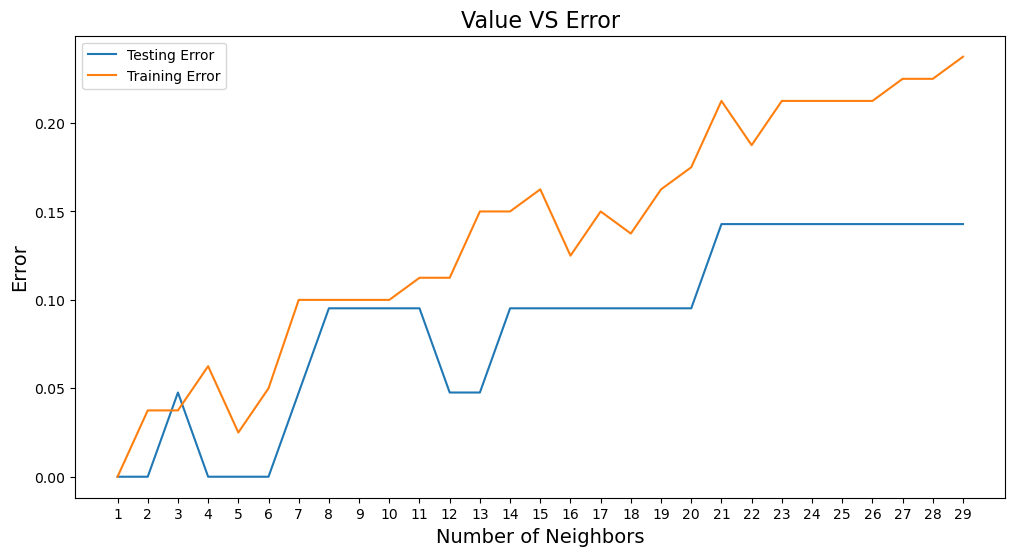

In [101]:
error1= []
error2= []
k_range = [i for i in range(1,30)]
for k in k_range:
    knn= KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)

    # Training predictions
    y_pred1= knn.predict(X_train)
    y_pred1 = y_pred1.reshape(80,1)
    error1.append(np.mean(y_train!= y_pred1))
    # Testing predictions
    y_pred2= knn.predict(X_test)
    y_pred2 = y_pred2.reshape(21,1)
    error2.append(np.mean(y_test!= y_pred2))

plt.figure(figsize=[12,6])
plt.plot(k_range, error2, label = 'Testing Error')
plt.plot(k_range, error1, label = 'Training Error')
plt.legend()
plt.title('Value VS Error', fontsize = 16)
plt.xlabel('Number of Neighbors', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
plt.xticks(k_range)
plt.show()

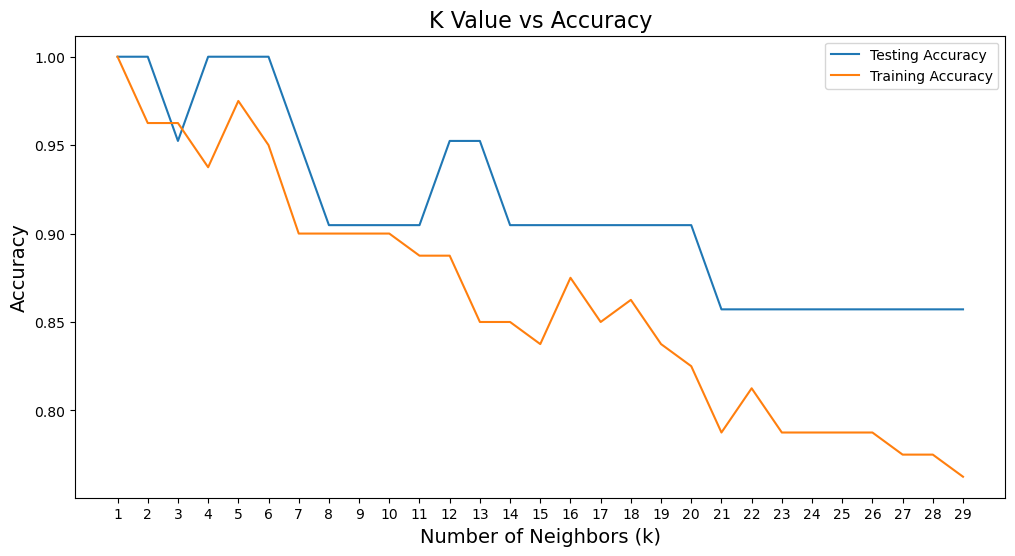

In [102]:
# Lists to store accuracy values for each k
train_accuracy = []
test_accuracy = []

# Define range of k values (1 to 29)
# Smaller k → more flexible model
# Larger k → smoother decision boundary
k_range = [i for i in range(1,30)]

# Loop through each k value, train KNN, and compute accuracy on training and test sets
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    train_accuracy.append(knn.score(X_train,y_train))
    test_accuracy.append(knn.score(X_test,y_test))

# -----------------------------
# Plot Accuracy vs K
# -----------------------------

plt.figure(figsize=(12,6))

# Plot testing accuracy curve
plt.plot(k_range, test_accuracy, label='Testing Accuracy')

# Plot training accuracy curve
plt.plot(k_range, train_accuracy, label='Training Accuracy')

# Add legend to distinguish curves
plt.legend()

# Add titles and axis labels
plt.title('K Value vs Accuracy', fontsize=16)
plt.xlabel('Number of Neighbors (k)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

# Show each k value on x-axis
plt.xticks(k_range)

# Display plot
plt.show()

## 7. Applying KNN

### 7.1 Applying KNN using K=3

We construct the model.

KNN using K = 3




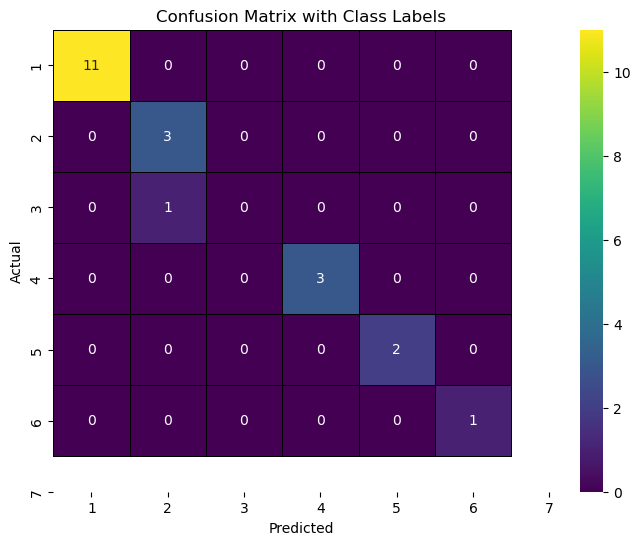



Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       0.75      1.00      0.86         3
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.79      0.83      0.81        21
weighted avg       0.92      0.95      0.93        21



In [103]:
# Create KNN classifier with k = 3 neighbors
# k controls how many nearest points vote in classification
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model using the training data
knn.fit(X_train, y_train)

#Evaluate on Test Data (Only Once)
# Predict labels for the test dataset
pred = knn.predict(X_test)

print('KNN using K = 3')
print('\n')

# Print confusion matrix
labels = knn.classes_
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            linewidths=0.5, 
            linecolor='black',
            xticklabels=labels, 
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Class Labels")
plt.show()

print('\n')

# Print classification report
# Includes precision, recall, F1-score, and support for each class
print("Classification Report:")
print(classification_report(y_test, pred))


As predicted by the `GridSearchCV`, the accuracy of this model is 95%. The model is extremely successful, with only one type 7 misclassification that fell into class 6. It is worth highlighting that the model did not overpredict in the end for type 1 animals, displaying an incredible performance.

### 7.2 Applying KNN using K=5

We now apply it for the K=5 case.

In [104]:
# Create a KNN classifier with k = 5 neighbors

KNN using K = 5




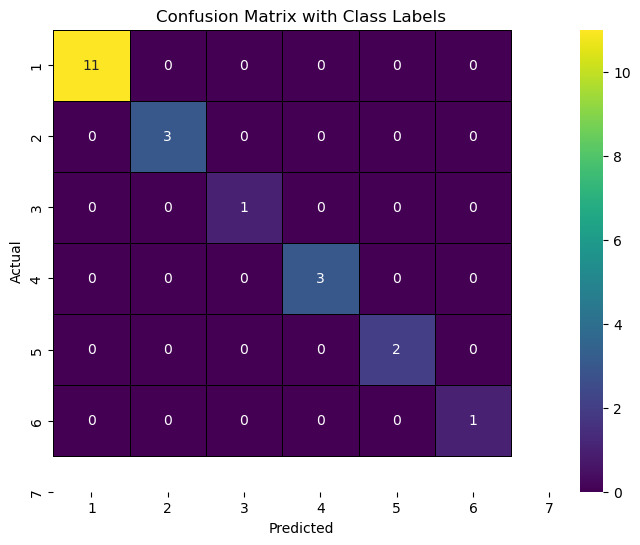



Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [105]:
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn.fit(X_train, y_train)

#Evaluate on Test Data (Only Once)
# Predict labels for the test dataset
pred = knn.predict(X_test)

print('KNN using K = 5')
print('\n')

# Print confusion matrix
labels = knn.classes_
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            linewidths=0.5, 
            linecolor='black',
            xticklabels=labels, 
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Class Labels")
plt.show()

print('\n')

# Print classification report
# Includes precision, recall, F1-score, and support for each class
print("Classification Report:")
print(classification_report(y_test, pred))


As expected after the Grid Search evaluations, the performance decreases. We note that one data point correctly classified by 3-NN from type 3 and 5 is now misclassified by 5-NN.


## 8. Conclusion:

The model was overall a complete success, and definitely recommendable for problems of this kind.